In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("procurement_buy_decision.csv")
print("Shape:", df.shape)
df.head()

Shape: (5330, 11)


,item,category,iso_year,iso_week,current_price_rs,price_change_4wk_pct,price_vs_3mo_avg_pct,days_to_festival,festival_season,expected_price_next_4wk_rs,target_buy_now
0,Samba Rice (1),Grocery/Staple,2022,24,160.28,0.00,0.00,305,0,170.92,1
1,Samba Rice (1),Grocery/Staple,2022,25,163.60,0.00,1.03,298,0,174.99,1
2,Samba Rice (1),Grocery/Staple,2022,26,168.96,0.00,2.85,291,0,179.31,1
3,Samba Rice (1),Grocery/Staple,2022,27,174.32,0.00,4.51,284,0,182.97,1
4,Samba Rice (1),Grocery/Staple,2022,28,176.80,10.31,4.74,277,0,186.45,1


In [2]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Missing values: 0
Duplicate rows: 0


In [3]:
df_clean = pd.get_dummies(df, columns=["item", "category"], drop_first=False)
print("Shape after encoding:", df_clean.shape)
df_clean.head()

Shape after encoding: (5330, 37)


,iso_year,iso_week,current_price_rs,price_change_4wk_pct,price_vs_3mo_avg_pct,days_to_festival,festival_season,expected_price_next_4wk_rs,target_buy_now,item_Banana (Ambul),...,item_Nadu Rice,item_Potatoes,item_Raw White Rice,item_Red Dhal,item_Red Onion (Sinnan),item_Samba Rice (1),item_Wheat Flour,item_White Sugar,category_Grocery/Staple,category_Vegetable/Fruit
0,2022,24,160.28,0.00,0.00,305,0,170.92,1,False,...,False,False,False,False,False,True,False,False,True,False
1,2022,25,163.60,0.00,1.03,298,0,174.99,1,False,...,False,False,False,False,False,True,False,False,True,False
2,2022,26,168.96,0.00,2.85,291,0,179.31,1,False,...,False,False,False,False,False,True,False,False,True,False
3,2022,27,174.32,0.00,4.51,284,0,182.97,1,False,...,False,False,False,False,False,True,False,False,True,False
4,2022,28,176.80,10.31,4.74,277,0,186.45,1,False,...,False,False,False,False,False,True,False,False,True,False


In [4]:
X = df_clean.drop(columns=["target_buy_now"])
y = df_clean["target_buy_now"]
print("Features:", X.shape, "| Target:", y.shape)

Features: (5330, 36) | Target: (5330,)


In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 3997 | Test: 1333


In [6]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                      subsample=0.9, eval_metric="logloss", random_state=42)
model.fit(X_train, y_train)
print("Model trained ✓")

Model trained ✓


Accuracy: 0.89
ROC-AUC : 0.96
              precision    recall  f1-score   support

        wait       0.88      0.87      0.88       593
     buy now       0.89      0.91      0.90       740

    accuracy                           0.89      1333
   macro avg       0.89      0.89      0.89      1333
weighted avg       0.89      0.89      0.89      1333



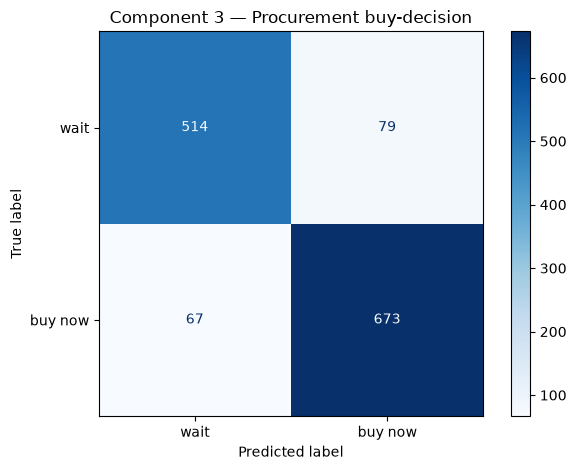

In [7]:
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba), 3))
print(classification_report(y_test, y_pred, target_names=["wait", "buy now"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=["wait", "buy now"], cmap="Blues")
plt.title("Component 3 — Procurement buy-decision"); plt.tight_layout(); plt.show()

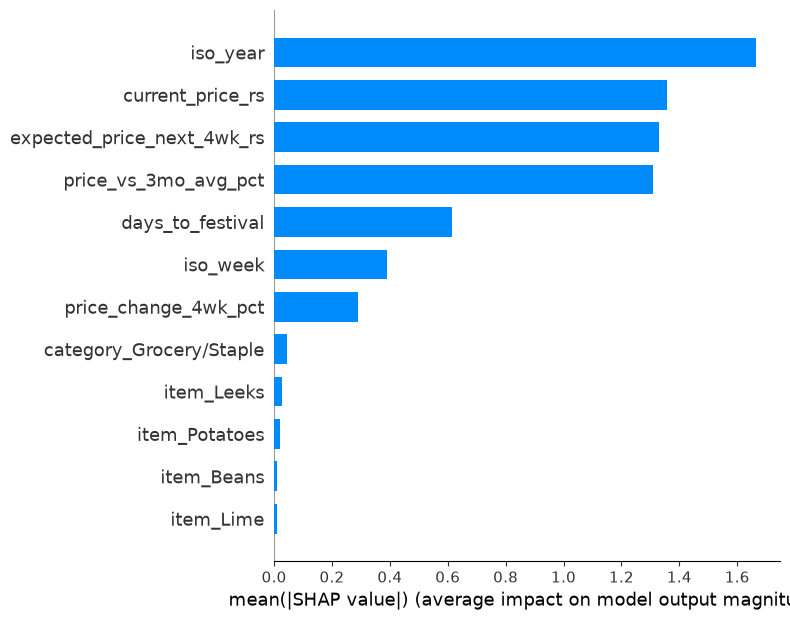

In [8]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=12)

In [9]:
import joblib
joblib.dump(model, "component3_procurement_model.pkl")
print("Saved as component3_procurement_model.pkl")

Saved as component3_procurement_model.pkl
